# Perceptrón

Un perceptrón es un modelo matemático utilizado en el área de la inteligencia artificial y el aprendizaje automático (*Machine Learning*). Fue desarrollado por Frank Rosenblatt en 1958 y está inspirado en el funcionamiento de las neuronas biológicas del cerebro humano.

Su principal función es recibir datos de entrada, procesarlos mediante pesos y una función de activación, y generar una salida o decisión. El perceptrón es considerado la unidad básica de las redes neuronales artificiales.

Este modelo funciona realizando una suma ponderada de las entradas:

\[
z = w_1x_1 + w_2x_2 + ... + b
\]

Donde:

- \(x\) representan las entradas.
- \(w\) representan los pesos.
- \(b\) es el sesgo (*bias*).

Posteriormente, el resultado pasa por una función de activación que determina la salida final.

El perceptrón se utiliza principalmente en tareas de clasificación, reconocimiento de patrones y predicción de datos. Además, es la base fundamental de las redes neuronales modernas y del aprendizaje profundo (*Deep Learning*).

### Aplicaciones del perceptrón

- Reconocimiento de imágenes.
- Clasificación de correos spam.
- Reconocimiento de voz.
- Diagnóstico médico.
- Sistemas de predicción.
- Vehículos autónomos.

Aunque el perceptrón simple tiene limitaciones para resolver problemas no lineales, su importancia radica en que fue el primer paso hacia el desarrollo de las redes neuronales artificiales actuales.

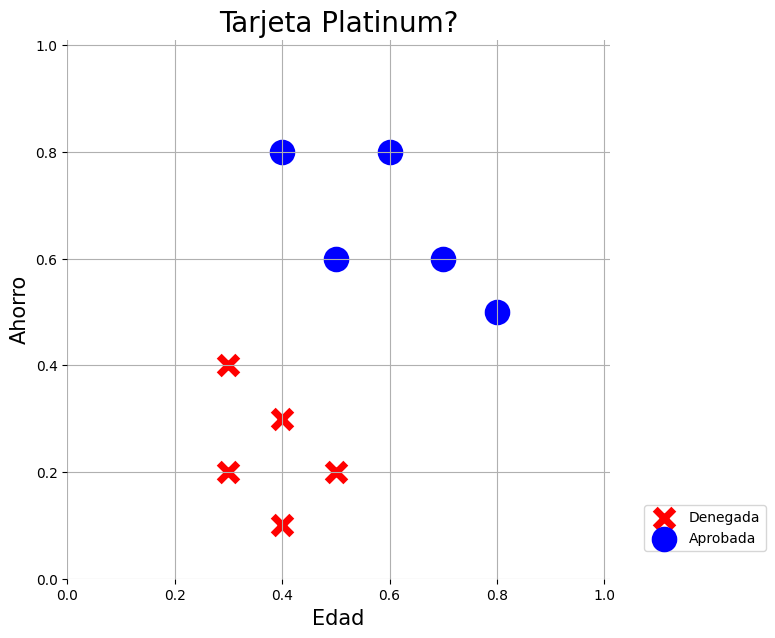

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de 10 personas -> [edad, ahorra]

personas = np.array([[0.3, 0.4],
                    [0.4, 0.3],
                    [0.3, 0.2], [0.4, 0.1],
                    [0.5, 0.2], [0.4, 0.8],
                    [0.6, 0.8], [0.5, 0.6],
                    [0.7, 0.6], [0.8, 0.5]])

#1 : aprobada 0 : denegada


clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Grafica de dispersion (edad, ahorro)
plt.figure(figsize=(7,7))
plt.title("Tarjeta Platinum?", fontsize=20)
plt.scatter (personas [clases == 0].T[0],
            personas [clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas [clases == 1].T[0],
            personas [clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

In [4]:
#w1*x1+w2*x2+ wnxn

def activacion(pesos, x, b):
    z = pesos * x
    if z.sum()+ b > 0:
      return 1
    else:
      return 0
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion (pesos, [0.5, 0.5], b)

(array([-0.91718777,  0.79350112]), 0.08757742728979956, 1)

In [8]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
    error_total = 0
    for i in range(len(personas)):
      prediccion = activacion (pesos, personas [i], b)
      error = clases[i] - prediccion
      error_total += error**2
      pesos [0] += tasa_de_aprendizaje * personas[i][0] * error
      pesos [1] += tasa_de_aprendizaje * personas[i][1] * error
      b += tasa_de_aprendizaje * error
    print(error_total, end=" ")

activacion(pesos, [0.5, 0.8], b)

8 9 9 9 9 9 9 9 9 9 8 9 9 9 9 9 9 9 9 9 9 9 8 9 9 9 9 9 9 9 7 7 7 7 7 7 7 7 8 7 7 7 7 7 7 7 7 6 7 6 6 7 5 5 6 5 5 5 6 5 5 5 6 5 5 6 5 5 5 4 4 5 4 5 4 5 4 4 5 4 5 4 4 4 5 4 4 5 4 4 4 5 4 3 4 3 2 2 3 2 

1

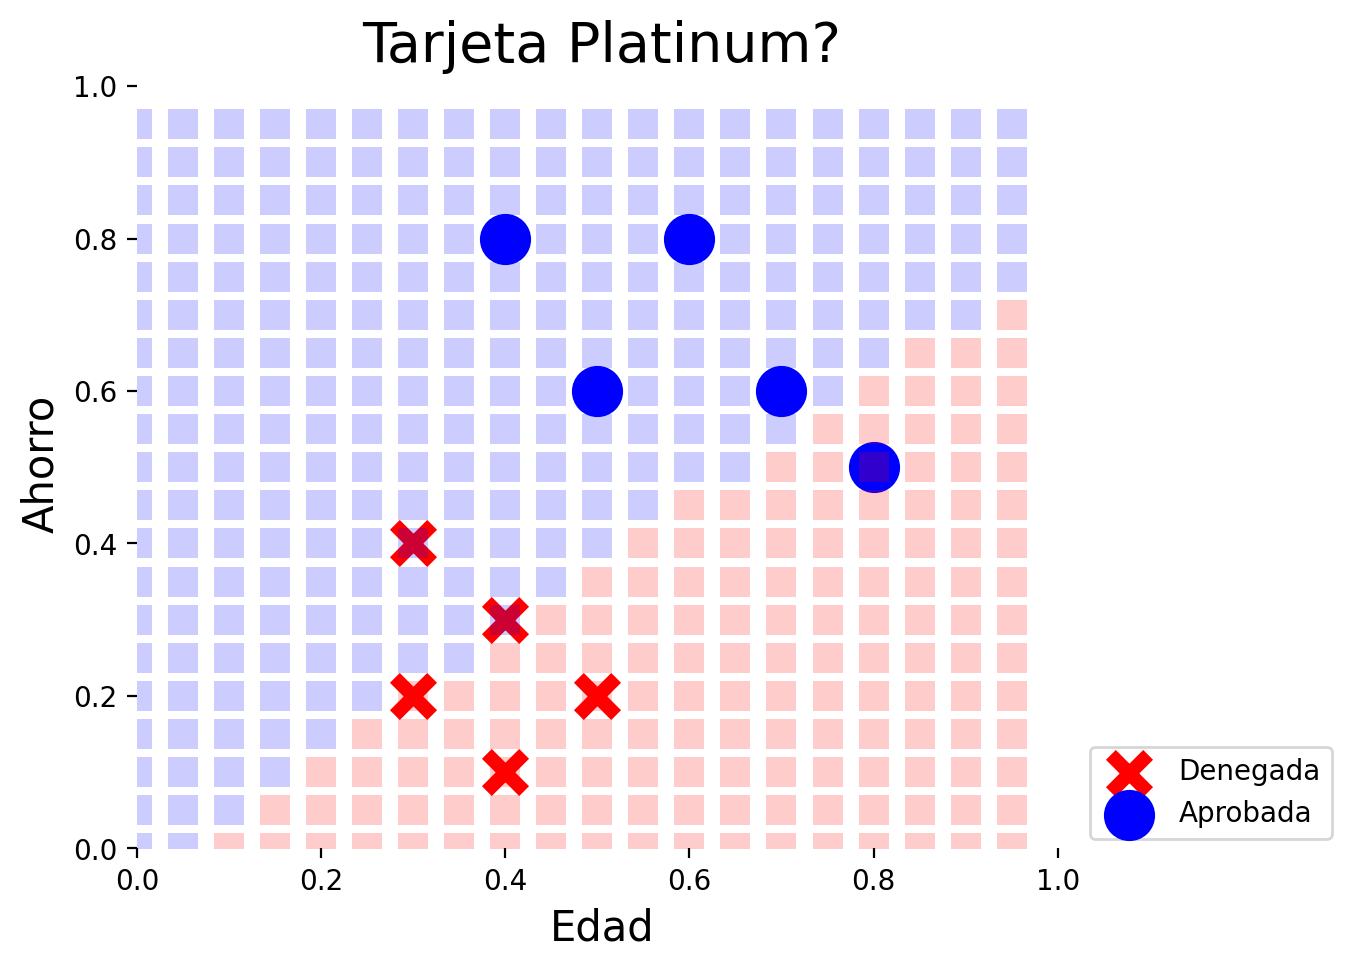

In [9]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s = 180, color="red",
            linewidths = 5, label="Denegada")

plt.scatter(personas [clases == 1].T[0],
            personas [clases == 1].T[1],
            marker="o", s = 180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activacion (pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s = 110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

In [10]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron().fit(personas, clases)
perceptron.predict([[0.2,0.2], [0.8, 0.8]])

array([0, 1])